# Sentiment Analysis on Reddit Posts

This proyect analyses Reddit's post about MSFT utilising TextBlob. The posts were download using an API Reddit.

### Libraries

In [103]:
#Reddit
import praw
#json
import json
#pandas
import pandas as pd
#utc_time
from datetime import datetime
#seaborn
import seaborn as sns


### Data ingestion

In [52]:
# Fetch latest posts from the subreddit and store in a local file

def fetch_and_store_reddit_data(subreddit_name="MSFT"): #topic
    subreddit = reddit.subreddit(subreddit_name)
    posts = []
    for post in subreddit.new(limit=1000):  # Limit to 100 posts
        post_data = {
            "id": post.id,
            "title": post.title,
            "author": post.author.name if post.author else None,
            "created_utc": post.created_utc,
            "selftext": post.selftext,
            "score": post.score,
            "comments": post.num_comments
            
        }
        posts.append(post_data)
        
    
    
    # Convert posts to JSON
    posts_json = json.dumps(posts, indent=4)
    
    # Define a fixed filename for overwriting
    local_filename = "msft_posts.json"
    
    # Write to local file system (this will overwrite the file each time)
    with open(local_filename, 'w') as local_file:
     for post in posts:
        local_file.write(json.dumps(post) + "\n")
    


    print(f"Data written to local file: {local_filename}")

# Call the function to fetch and store Reddit data
fetch_and_store_reddit_data("msft")

Data written to local file: msft_posts.json


In [39]:
with open('msft_posts.json') as user_file:
  df = user_file.read()

print(df)

{"id": "1rli58m", "title": "Latest data on MSFT", "author": "AcanthisittaHour4995", "created_utc": 1772718690.0, "selftext": "https://preview.redd.it/3ds7d9gpe8ng1.png?width=933&format=png&auto=webp&s=6b07baea9a09aa8f238d4e9462c6778541f3c288\n\n", "score": 0, "comments": 0}
{"id": "1rin77n", "title": "MSFT: Geopolitical Shock: US-Iran Strikes & UAE Data Center Fire", "author": "ugos1", "created_utc": 1772439379.0, "selftext": "", "score": 1, "comments": 0}
{"id": "1rggbf2", "title": "is it a good time to get in? MSFT Stock", "author": "Appropriate-Mood-108", "created_utc": 1772220446.0, "selftext": "I have lost a lot of money in stock market and want to make up for it. Since MSFT dropped significantly lately, is it a good time to get in? ", "score": 4, "comments": 1}
{"id": "1recq41", "title": "Decide to Trade MSFT Futures", "author": "Aggressive-Virus4046", "created_utc": 1772024864.0, "selftext": "", "score": 3, "comments": 0}
{"id": "1rda4ju", "title": "MSFT AI Panic: Buy the Fear?"

In [84]:
df = pd.read_json('msft_posts.json', lines = True)

In [69]:
df.shape

(54, 7)

In [70]:
df.head()

,id,title,author,created_utc,selftext,score,comments
0,1rli58m,Latest data on MSFT,AcanthisittaHour4995,1772718690,https://preview.redd.it/3ds7d9gpe8ng1.png?widt...,0,0
1,1rin77n,MSFT: Geopolitical Shock: US-Iran Strikes & UA...,ugos1,1772439379,,1,0
2,1rggbf2,is it a good time to get in? MSFT Stock,Appropriate-Mood-108,1772220446,I have lost a lot of money in stock market and...,3,1
3,1recq41,Decide to Trade MSFT Futures,Aggressive-Virus4046,1772024864,,3,0
4,1rda4ju,MSFT AI Panic: Buy the Fear?,ugos1,1771919340,,2,0


##### Adjusting time

In [ ]:
def convert_time(UTC_time):
    regular_time = datetime.utcfromtimestamp(UTC_time)
    return regular_time

df['created_utc'] = df['created_utc'].apply(convert_time)

### TextBlob

TextBlob is a Python library for processing textual data. It provides a simple API for diving into common natural language processing (NLP) tasks such as part-of-speech tagging, noun phrase extraction, sentiment analysis, classification, and more.

In [64]:
from textblob import TextBlob
def get_sentiment(text):
    if text:
        return TextBlob(text).sentiment.polarity
    return 0.0

In [93]:
df['sentiment'] = df['selftext'].apply(get_sentiment)

In [94]:
df.head()

,id,title,author,created_utc,selftext,score,comments,sentiment
0,1rli58m,Latest data on MSFT,AcanthisittaHour4995,2026-03-05 13:51:30,https://preview.redd.it/3ds7d9gpe8ng1.png?widt...,0,0,0.0
1,1rin77n,MSFT: Geopolitical Shock: US-Iran Strikes & UA...,ugos1,2026-03-02 08:16:19,,1,0,0.0
2,1rggbf2,is it a good time to get in? MSFT Stock,Appropriate-Mood-108,2026-02-27 19:27:26,I have lost a lot of money in stock market and...,3,1,0.7
3,1recq41,Decide to Trade MSFT Futures,Aggressive-Virus4046,2026-02-25 13:07:44,,3,0,0.0
4,1rda4ju,MSFT AI Panic: Buy the Fear?,ugos1,2026-02-24 07:49:00,,2,0,0.0


### Sentiment by day

In [95]:
#  aggregate sentiment per day
daily_sentiment = df.groupby('created_utc').agg({'sentiment': 'mean'}).reset_index()

In [96]:
daily_sentiment

,created_utc,sentiment
0,2021-08-20 19:47:43,-0.125000
1,2021-08-20 19:48:41,0.000000
2,2021-08-20 19:49:54,0.132143
3,2021-08-20 19:50:52,0.000000
4,2021-08-20 19:54:23,0.000000
5,2022-12-12 04:36:23,0.000000
6,2023-07-26 22:11:09,0.000000
7,2023-09-23 14:47:59,0.000000
8,2023-10-06 12:32:22,0.000000
9,2024-03-21 16:13:57,0.000000


### Sentiment by label (positive, neutral, negative)

In [97]:
def categorize_sentiment(value):
    if value > 0.1:
        return "Positive"
    elif value < -0.1:
        return "Negative"
    else:
        return "Neutral"
df["sentiment_label"] = df["sentiment"].apply(categorize_sentiment)

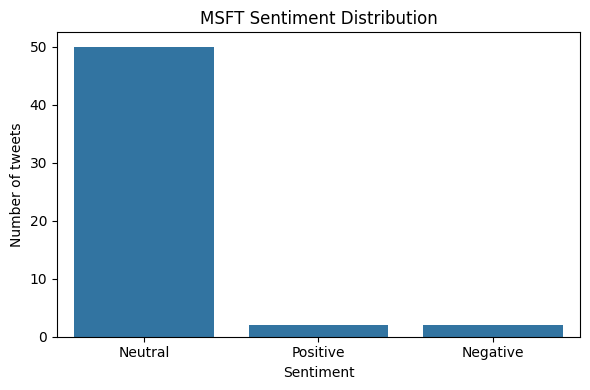

In [102]:
#plot
# Count sentiment labels
sentiment_counts = df["sentiment_label"].value_counts().reset_index()
sentiment_counts.columns = ["Sentiment", "Count"]

# Plot
plt.figure(figsize=(6, 4))
sns.barplot(data=sentiment_counts, x="Sentiment", y="Count")
plt.title("MSFT Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of tweets")
plt.tight_layout()
plt.show()

In [101]:
sentiment_counts

,Sentiment,Count
0,Neutral,50
1,Positive,2
2,Negative,2
